In [ ]:
pip install pandas numpy scikit-learn nltk torch transformers datasets matplotlib seaborn

In [ ]:
import os
import re
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# NLP Libraries
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

# Machine Learning & Evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, f1_score, accuracy_score, confusion_matrix

# Reproducibility
SEED = 42
np.random.seed(SEED)

In [ ]:
df = pd.read_csv("/content/amazonreviews.tsv", sep='\t')
df

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."
...,...,...
9995,pos,A revelation of life in small town America in ...
9996,pos,Great biography of a very interesting journali...
9997,neg,Interesting Subject; Poor Presentation: You'd ...
9998,neg,Don't buy: The box looked used and it is obvio...


In [ ]:
df.shape

(10000, 2)

In [ ]:
df.head()

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


In [ ]:
df.columns

Index(['label', 'review'], dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


In [ ]:
df.describe(include="all")

,label,review
count,10000,10000
unique,2,10000
top,neg,Early Hopkins story still sends chills through...
freq,5097,1


In [ ]:
df.isnull().sum()

,0
label,0
review,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['label'].value_counts()

,count
label,
neg,5097
pos,4903


In [ ]:
f = df.dropna(subset=["review", "label"])

In [ ]:
df = df.drop_duplicates()

# Check the dataset again:
print("Dataset Shape After Cleaning:", df.shape)

Dataset Shape After Cleaning: (10000, 2)


In [ ]:
import string
nltk.download('wordnet', quiet=True)
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):

    # Convert text to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    text = re.sub(r'\d+', ' ', text)

    # Tokenization
    words = text.split()

    # Remove stopwords and lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    # Join words
    return " ".join(words)

df["clean_review"] = df["review"].astype(str).apply(preprocess_text)

# Display original and cleaned reviews:
df[["review", "clean_review"]].head()

,review,clean_review
0,Stuning even for the non-gamer: This sound tra...,stuning even nongamer sound track beautiful pa...
1,The best soundtrack ever to anything.: I'm rea...,best soundtrack ever anything im reading lot r...
2,Amazing!: This soundtrack is my favorite music...,amazing soundtrack favorite music time hand in...
3,Excellent Soundtrack: I truly like this soundt...,excellent soundtrack truly like soundtrack enj...
4,"Remember, Pull Your Jaw Off The Floor After He...",remember pull jaw floor hearing youve played g...


In [ ]:
df["sentiment"] = df["label"].map({
    "pos": 1,
    "neg": 0
})

# Check the result:

df[["label", "sentiment"]].head()

,label,sentiment
0,pos,1
1,pos,1
2,pos,1
3,pos,1
4,pos,1


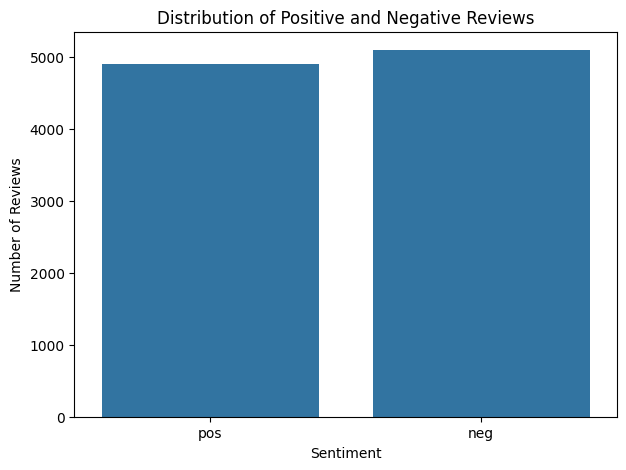

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="label"
)

plt.title("Distribution of Positive and Negative Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

In [ ]:
positive_reviews = df[df["label"] == "pos"]["clean_review"]
negative_reviews = df[df["label"] == "neg"]["clean_review"]

# Combine all positive reviews:

positive_text = " ".join(positive_reviews)

# Combine all negative reviews:

negative_text = " ".join(negative_reviews)

# Find the most common positive words:

positive_words = Counter(positive_text.split())

print("Most Common Positive Words:")
print(positive_words.most_common(20))

# Find the most common negative words:

negative_words = Counter(negative_text.split())

print("Most Common Negative Words:")
print(negative_words.most_common(20))

Most Common Positive Words:
[('book', 3861), ('great', 2089), ('one', 1936), ('good', 1637), ('read', 1574), ('like', 1320), ('movie', 1295), ('time', 1136), ('love', 1038), ('would', 943), ('get', 936), ('well', 857), ('story', 857), ('really', 828), ('best', 801), ('first', 708), ('make', 705), ('work', 679), ('year', 677), ('much', 650)]
Most Common Negative Words:
[('book', 3683), ('one', 2119), ('movie', 1732), ('like', 1570), ('would', 1438), ('get', 1285), ('time', 1275), ('dont', 1240), ('read', 1238), ('good', 1137), ('even', 898), ('buy', 821), ('really', 778), ('much', 769), ('make', 761), ('work', 761), ('story', 756), ('bad', 749), ('money', 747), ('first', 736)]


In [ ]:
# Install/import WordCloud:

from wordcloud import WordCloud

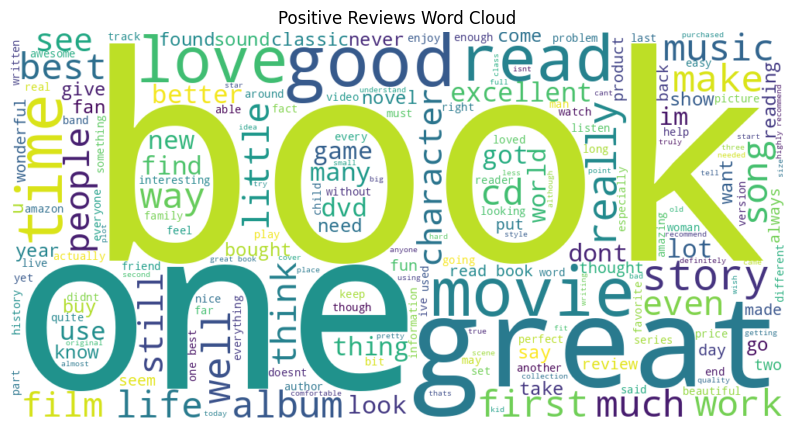

In [ ]:
plt.figure(figsize=(10,6))

wordcloud_positive = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(positive_text)

plt.imshow(wordcloud_positive, interpolation="bilinear")
plt.axis("off")
plt.title("Positive Reviews Word Cloud")
plt.show()

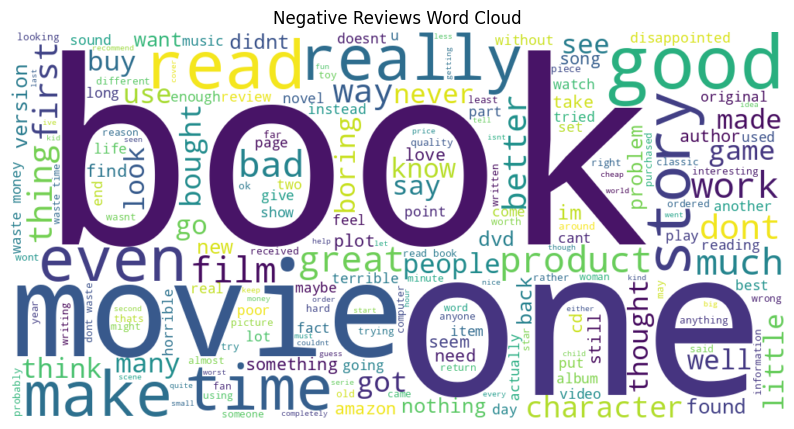

In [ ]:
plt.figure(figsize=(10,6))

wordcloud_negative = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(negative_text)

plt.imshow(wordcloud_negative, interpolation="bilinear")
plt.axis("off")
plt.title("Negative Reviews Word Cloud")
plt.show()

In [ ]:
X = df["clean_review"]
y = df["sentiment"]

# Create the TF-IDF vectorizer:

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

# Transform the reviews:

X_tfidf = tfidf.fit_transform(X)

print("TF-IDF Shape:", X_tfidf.shape)

TF-IDF Shape: (10000, 10000)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train, y_train)

# Make predictions:

y_pred_lr = logistic_model.predict(X_test)

# Calculate accuracy:

accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:",
      accuracy_lr)

# Calculate F1-score:

f1_lr = f1_score(y_test, y_pred_lr)

print("Logistic Regression F1 Score:",
      f1_lr)

# Classification report:

print(classification_report(
    y_test,
    y_pred_lr,
    target_names=["Negative", "Positive"]
))

Logistic Regression Accuracy: 0.855
Logistic Regression F1 Score: 0.8517382413087935
              precision    recall  f1-score   support

    Negative       0.86      0.86      0.86      1019
    Positive       0.85      0.85      0.85       981

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



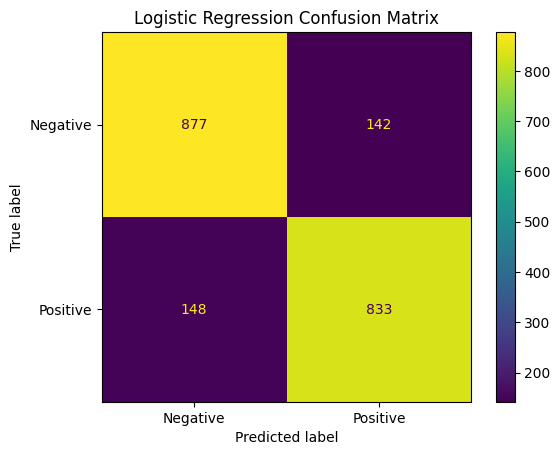

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

cm_lr = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["Negative", "Positive"]
)

disp.plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [ ]:
svm_model = LinearSVC(
    random_state=42
)

svm_model.fit(X_train, y_train)

# Make predictions:

y_pred_svm = svm_model.predict(X_test)

# Calculate accuracy:

accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:",
      accuracy_svm)

# Calculate F1-score:

f1_svm = f1_score(y_test, y_pred_svm)

print("SVM F1 Score:",
      f1_svm)

# Classification report:

print(classification_report(
    y_test,
    y_pred_svm,
    target_names=["Negative", "Positive"]
))

SVM Accuracy: 0.8425
SVM F1 Score: 0.8403446528129752
              precision    recall  f1-score   support

    Negative       0.85      0.84      0.84      1019
    Positive       0.84      0.85      0.84       981

    accuracy                           0.84      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.84      0.84      0.84      2000



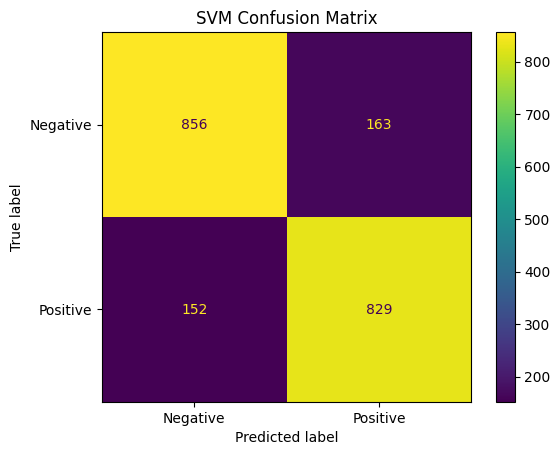

In [ ]:
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=["Negative", "Positive"] )
disp.plot()
plt.title("SVM Confusion Matrix")
plt.show()

                 Model  Accuracy  F1 Score
0  Logistic Regression    0.8550  0.851738
1                  SVM    0.8425  0.840345


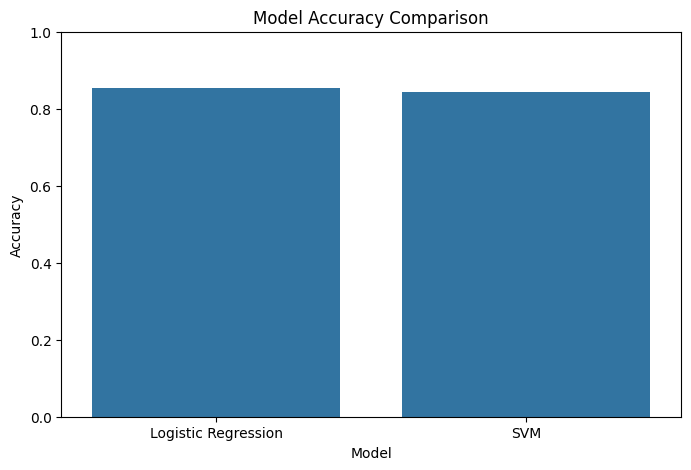

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_svm
    ],
    "F1 Score": [
        f1_lr,
        f1_svm
    ]
})

print(results)

# Visualize model accuracy:

plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    logistic_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores:")
print(cv_scores)

print("Mean CV Accuracy:",
      cv_scores.mean())

Cross Validation Scores:
[0.864375 0.856875 0.870625 0.855625 0.85375 ]
Mean CV Accuracy: 0.86025


In [ ]:
new_review = [
    "The product quality is excellent and I really love it"
]

# Preprocess the review:

new_review_clean = [
    preprocess_text(review)
    for review in new_review
]

# Convert to TF-IDF:

new_review_tfidf = tfidf.transform(
    new_review_clean
)

# Predict sentiment:

prediction = svm_model.predict(
    new_review_tfidf
)

if prediction[0] == 1:
    print("Positive Review")
else:
    print("Negative Review")
# 22. Test Another Review
new_review = [
    "The product is terrible and stopped working after one day"
]

new_review_clean = [
    preprocess_text(review)
    for review in new_review
]

new_review_tfidf = tfidf.transform(
    new_review_clean
)

prediction = svm_model.predict(
    new_review_tfidf
)

if prediction[0] == 1:
    print("Positive Review")
else:
    print("Negative Review")

Positive Review
Negative Review


In [ ]:
new_review = [
    "The product is terrible and stopped working after one day"
]

new_review_clean = [
    preprocess_text(review)
    for review in new_review
]

new_review_tfidf = tfidf.transform(
    new_review_clean
)

prediction = svm_model.predict(
    new_review_tfidf
)

if prediction[0] == 1:
    print("Positive Review")
else:
    print("Negative Review")

Negative Review
